In [30]:
%pip install -q sysidentpy numpy scipy torch scikit-learn

import time
import os
from pathlib import Path

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import combinations_with_replacement
from sysidentpy.neural_network import NARXNN
from sysidentpy.basis_function import Polynomial

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

try:
    # Collega Google Drive (colab fallback supportato da VS Code)
    from google.colab import drive
    drive.mount('/content/drive')
    
    # IMPORTANTE: Modifica questo percorso col path del tuo file su google drive!
    # Puoi caricare manualmente la cartella Benchmark_EEG_small nel tuo Drive.
    data_path = Path('/content/drive/MyDrive/Benchmark_EEG_small/Benchmark_EEG_small.mat')
    
except ImportError:
    # Fallback per l'esecuzione in locale
    data_path = Path('./Benchmark_EEG_small/Benchmark_EEG_small.mat')

data = sio.loadmat(data_path)
u_3d = data['data']['u'].item()  # shape: (10, 7, 256)
y_3d = data['data']['y'].item()  # EEG output

u_trials = u_3d.reshape(-1, 256)
y_trials = y_3d.reshape(-1, 256)

n_trials = u_trials.shape[0]

print(f"Loaded dataset with {u_trials.size} samples")

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Loaded dataset with 17920 samples


In [ ]:
# Time-ordered split: train/val/test = 70/15/15
n = len(u)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

u_train, u_val, u_test = u[:n_train], u[n_train:n_train + n_val], u[n_train + n_val:]
y_train, y_val, y_test = y[:n_train], y[n_train:n_train + n_val], y[n_train + n_val:]

scaler_u = StandardScaler()
scaler_y = StandardScaler()

u_train_s = scaler_u.fit_transform(u_train)
y_train_s = scaler_y.fit_transform(y_train)
u_val_s = scaler_u.transform(u_val)
y_val_s = scaler_y.transform(y_val)
u_test_s = scaler_u.transform(u_test)
y_test_s = scaler_y.transform(y_test)

NY = 10
NU = 10
DEGREE = 2

print(f"Train: {len(u_train)} | Val: {len(u_val)} | Test: {len(u_test)}")

In [33]:
class NARXNet(nn.Module):
    def __init__(self, input_size, hidden_1=128, hidden_2=64, hidden_3=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_1),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(hidden_1, hidden_2),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(hidden_2, hidden_3),
            nn.Tanh(),
            nn.Linear(hidden_3, 1),
        )

    def forward(self, x):
        return self.net(x)


def narx_regressor_count(ny, nu, degree=2):
    # Number of polynomial terms up to 'degree', excluding bias.
    m = ny + nu
    if degree != 2:
        raise ValueError("This helper currently supports degree=2.")
    linear_terms = m
    quadratic_terms = m * (m + 1) // 2
    return linear_terms + quadratic_terms


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def estimate_mlp_flops_per_sample(input_size, hidden_1=64, hidden_2=32, output_size=1):
    # Approximate FLOPs for Linear layers only: 2 * in * out (mul + add).
    return (
        2 * input_size * hidden_1
        + 2 * hidden_1 * hidden_2
        + 2 * hidden_2 * output_size
    )

In [34]:


input_size = narx_regressor_count(ny=NY, nu=NU, degree=DEGREE)
net = NARXNet(input_size=input_size, hidden_1=64, hidden_2=32)

model = NARXNN(
    net=net,
    ylag=NY,
    xlag=NU,
    basis_function=Polynomial(degree=DEGREE ),
    loss_func='mse_loss',
    optimizer='Adam',
    optim_params={},
    epochs=500,
    learning_rate=0.00001,
    batch_size=128,
    verbose=False,
)

print(f"NARX input size: {input_size}")
print(f"Trainable params: {count_trainable_params(net)}")
print(f"Approx FLOPs/sample: {estimate_mlp_flops_per_sample(input_size):,}")

NARX input size: 230
Trainable params: 17953
Approx FLOPs/sample: 33,600


In [35]:
print("Training NARX...")
t0 = time.perf_counter()
model.fit(X=u_train_s, y=y_train_s)
train_time_s = time.perf_counter() - t0
print(f"Training completed in {train_time_s:.2f} s")


Training NARX...
Training completed in 29.19 s


In [36]:
# One-step prediction on validation and test
yhat_val_1_s = model.predict(X=u_val_s, y=y_val_s, steps_ahead=1)
yhat_test_1_s = model.predict(X=u_test_s, y=y_test_s, steps_ahead=1)

# Multi-step free-run simulation on validation and test
yhat_val_m_s = model.predict(X=u_val_s, y=y_val_s)
yhat_test_m_s = model.predict(X=u_test_s, y=y_test_s)

# Back to original scale
yhat_val_1 = scaler_y.inverse_transform(yhat_val_1_s)
yhat_test_1 = scaler_y.inverse_transform(yhat_test_1_s)
yhat_val_m = scaler_y.inverse_transform(yhat_val_m_s)
yhat_test_m = scaler_y.inverse_transform(yhat_test_m_s)

In [41]:
def align_true_pred(y_true, y_pred):
    y_pred = np.asarray(y_pred).reshape(-1)
    y_true = np.asarray(y_true).reshape(-1)
    n = min(len(y_true), len(y_pred))
    return y_true[-n:], y_pred[-n:]


def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.max(y_true) - np.min(y_true)
    return rmse / denom if denom > 0 else np.nan


def vaf(y_true, y_pred):
    denom = np.var(y_true)
    return (1 - np.var(y_true - y_pred) / denom) * 100 if denom > 0 else np.nan


def evaluate(y_true_full, y_pred):
    y_true_a, y_pred_a = align_true_pred(y_true_full, y_pred)
    mse = mean_squared_error(y_true_a, y_pred_a)
    rmse = np.sqrt(mse)
    return {
        "MSE": mse,
        "RMSE": rmse,
        "NRMSE": nrmse(y_true_a, y_pred_a),
        "VAF": vaf(y_true_a, y_pred_a),
    }

In [42]:
results = {
    "val_1step": evaluate(y_val, yhat_val_1),
    "val_multistep": evaluate(y_val, yhat_val_m),
    "test_1step": evaluate(y_test, yhat_test_1),
    "test_multistep": evaluate(y_test, yhat_test_m),
}

print("\n=== NARX Results ===")
for name, values in results.items():
    print(f"\n[{name}]")
    print(f"MSE   : {values['MSE']:.6f}")
    print(f"RMSE  : {values['RMSE']:.6f}")
    print(f"NRMSE : {values['NRMSE']:.4f} ({values['NRMSE'] * 100:.2f}%)")
    print(f"VAF   : {values['VAF']:.2f}%")

print("\n=== Complexity / Time ===")
print(f"Train time [s]     : {train_time_s:.2f}")
print(f"Trainable params   : {count_trainable_params(net)}")
print(f"Approx FLOPs/sample: {estimate_mlp_flops_per_sample(input_size):,}")


=== NARX Results ===

[val_1step]
MSE   : 1.385751
RMSE  : 1.177179
NRMSE : 0.1898 (18.98%)
VAF   : -42.49%

[val_multistep]
MSE   : 1.109866
RMSE  : 1.053502
NRMSE : 0.1698 (16.98%)
VAF   : -13.96%

[test_1step]
MSE   : 0.098342
RMSE  : 0.313596
NRMSE : 0.0481 (4.81%)
VAF   : 89.83%

[test_multistep]
MSE   : 1.227501
RMSE  : 1.107926
NRMSE : 0.1701 (17.01%)
VAF   : -26.90%

=== Complexity / Time ===
Train time [s]     : 29.19
Trainable params   : 17953
Approx FLOPs/sample: 33,600


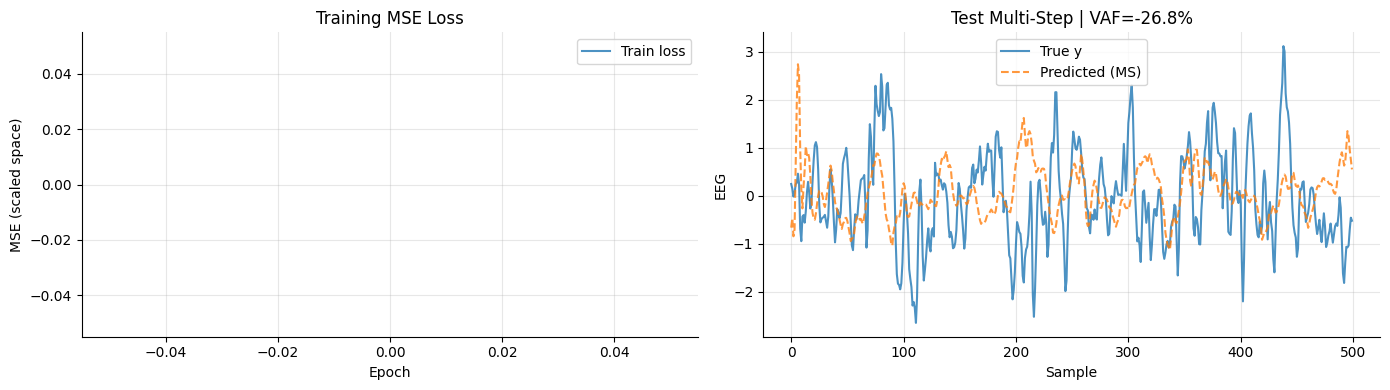

In [39]:
# ── Training curve ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
if hasattr(model, 'train_loss'):
    axes[0].plot(model.train_loss, label='Train loss', alpha=0.8)
    axes[0].set_title('Training MSE Loss')
else:
    axes[0].set_title('Training MSE (Loss history not available)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (scaled space)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Multi-step prediction on test set
n_show = 500
# evaluate() aligned arrays, so we need to fetch the aligned versions for correct plotting
y_true_a, y_pred_a = align_true_pred(y_test, yhat_test_m)
axes[1].plot(y_true_a[:n_show],    label='True y',        alpha=0.8)
axes[1].plot(y_pred_a[:n_show],    label='Predicted (MS)', alpha=0.8, linestyle='--')
axes[1].set_title(f'Test Multi-Step | VAF={results["test_multistep"]["VAF"]:.1f}%')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('EEG')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('narx_results.png', dpi=150)
plt.show()